ND convolutiosn using FFT and convolution theorem

Verified with natural domain equivalence
First element matches
Mismatch in other elements due to padding effect

Check once: Must match perfectly with circular convolution

---

Kishore Kumar Tarafdar, Date: 07-06-2025


In [1]:
pwd

'/data1/kishoretarafdar/src.port/NLSI.v0'

In [1]:
!python --version

Python 3.12.7


        Disable GPU: Force tensorflow to select CPU

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"    
import tensorflow as tf

2025-07-03 04:42:06.570926: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751497926.592910  355522 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751497926.599523  355522 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 04:42:06.622036: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


        Select a GPU with a memory limit

In [1]:
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)

2025-07-02 22:29:20.425416: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751475560.446067  222648 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751475560.452448  222648 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-02 22:29:20.474063: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version 2.18.0
Num GPUs Available:  3


3

Select one GPU

        Restrict code to use a particular GPU...

In [2]:
# # include ../dirx 
mylibpath = [
    '/home/kishoretarafdar/bin',
    # '/data1/kishoretarafdar/src.port/NSLI.v00/utils.Volterra'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(0,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu

In [5]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [3]:
# select_gpu = gpus[gpu_id]
memory_limit = 32 #GB
select_a_gpu(gpus, gpu_id=1, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

3 Physical GPUs available 
Selected 1 Logical GPU with 32 GB memory limit


I0000 00:00:1751475572.782663  222648 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 32768 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:23:00.0, compute capability: 8.6


In [7]:
def get_kernel_padding_from_input(input_shape, N, L):
    """
    Generate paddings for kernel tensor to match spatial size N from L,
    using input_shape to determine number of spatial dimensions.

    Args:
        input_shape: tf.TensorShape or tuple/list of shape (batch, D1, ..., Dn, in_channels)
        N: target spatial size (assumed same for all dims)
        L: original kernel size (assumed same for all spatial dims)

    Returns:
        paddings: list of [0, N - L] for each spatial dim + [[0, 0], [0, 0]] for in/out channels
    """
    num_spatial_dims = len(input_shape) - 2  # Exclude batch and channels
    paddings = [[0, N - L] for _ in range(num_spatial_dims)]  # spatial dims
    paddings += [[0, 0], [0, 0]]  # in_channels, out_channels
    return paddings


# Example usage
n = 10
input_shape = (1, n, n, n, n, 1)
x = tf.random.normal(input_shape)  # Example input with shape (batch_size=1, height=28, width=28, channels=1)
        
# Create the custom Conv2D layer with 16 filters and a 3x3 kernel size
# custom_conv_layer = FFTConvND(filters=1)
# custom_conv_layer = ConvND(filters=2)
# ytrans = custom_conv_layer(x)
        
# print(ytrans.shape) 


L = 2  # e.g., (L, L, in_ch, out_ch)
paddings = get_kernel_padding_from_input(input_shape, n, L)
paddings
# h1_padded = tf.pad(self.h1, paddings, mode='CONSTANT', constant_values=0)


[[0, 8], [0, 8], [0, 8], [0, 8], [0, 0], [0, 0]]

In [288]:
def get_kernel_perms(input_shape):
    """
    Given input shape: (batch, D1, D2, ..., Dn, in_channels)
    Returns:
        - first_perm: for kernel: (D1, D2, ..., Dn, in_channels, out_channels) → (out_channels, D1, ..., Dn, in_channels)
        - second_perm: to bring it back → (D1, ..., Dn, in_channels, out_channels)
    """
    num_spatial_dims = len(input_shape) - 2  # Exclude batch and channels

    # perm to move output channels (last) to front
    first_perm = [num_spatial_dims + 1] + list(range(num_spatial_dims)) + [num_spatial_dims]
    
    # perm to move output channels back to end
    second_perm = list(range(1, num_spatial_dims + 1)) + [num_spatial_dims + 1, 0]

    return first_perm, second_perm

input_shape = (None, 8, 8, 8, 8, 1)  # 3D input: batch, D1, D2, D3, channels
perm1, perm2 = get_kernel_perms(input_shape)

perm1, perm2
# kernel = tf.transpose(kernel, perm=perm1)  # Move output channels to front
# kernel_fft = self.__fftnd(tf.cast(kernel, tf.complex64), axes=self.axes)
# kernel_fft = tf.transpose(kernel_fft, perm=perm2)  # Move output channels to the end


([5, 0, 1, 2, 3, 4], [1, 2, 3, 4, 5, 0])

# FFT based ND convolutions

        Export to py file

In [8]:
#%% Checked equivalence of natural and fft domain
## Equivalent to cyclic convolution
import tensorflow as tf

class FFTConvND(tf.keras.layers.Layer):
    """ ND convolutions using convolution theorem 
        Separable FFTND

        Equivalent to circular convolution

        tf.pad limitation: Only ranks up to 6 supported: [2,2,2,2,2,2,4] [Op:Pad]
        Therefore this layer supports upto 5D convs!!
        
        patch update tf_pad_nd method for 6D 
        Current limitation: einsum table hardcoded till 6D conv

        Note: there will be error if L>N


        VolterraSys: Multidimensional linear and nonlinear Volterra kernels in natural and biortogonal bases.
        Copyright (C) 2025 Kishore Kumar Tarafdar

        This program is free software: you can redistribute it and/or modify
        it under the terms of the GNU General Public License as published by
        the Free Software Foundation, either version 3 of the License, or
        (at your option) any later version.

        This program is distributed in the hope that it will be useful,
        but WITHOUT ANY WARRANTY; without even the implied warranty of
        MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
        GNU General Public License for more details.

        You should have received a copy of the GNU General Public License
        along with this program.  If not, see <https://www.gnu.org/licenses/>.   
        
    --kkt@07-Jun-2025"""
    def __init__(self, filters, kernel_size=9):#, l1=0.0, l2=0.0):
        super(FFTConvND, self).__init__()
        self.filters = filters
        self.kernel_size = kernel_size
        # self.dim = dim
        # self.axes = axes

   
    def build(self, input_shape):
        self.N = input_shape[1] ## !!hyper square inputs only
        self.axes = list(range(1, len(input_shape) - 1))
        self.dim = self.axes[-1]
        in_channels = input_shape[-1] 
        
        # Initialize the kernel with the specified shape
        ##OPTION 1: NO PADDING and L=N by default
        # *input_shape[]
        # kernel_size = input_shape[1:self.dim+1] 
        # kernel_shape = kernel_size + (input_shape[-1], self.filters)      

        ##OPTION 2: [update applied] for smaller size kernels
        kernel_shape = [self.kernel_size] * self.dim + [in_channels, self.filters]
        self.kernel = self.add_weight(
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            name='kernel'
        )
        
    def call(self, x):
        print(x.shape, self.kernel.shape, x.dtype, self.kernel.dtype)
        ## FFT of input and kernel 
        x_fft = self.__fftnd(tf.cast(x, tf.complex64), axes=self.axes)
        
        ##OPTION 1: NO PADDING and L=N by default
        # kernel_fft = self.__fftnd(tf.cast(self.kernel, tf.complex64), axes=self.axes)
        
        ##OPTION 2: [update applied] for smaller size kernels
        kernel = self._pad_kernel_to_match_input_shape()
        
        ## fixed here n,n,i,o ----- dynamic perm based in input dim---
        perm1, perm2 = self._get_kernel_perms()
        kernel = tf.transpose(kernel,perm=perm1) ## o,n,n,i
        kernel_fft = self.__fftnd(tf.cast(kernel, tf.complex64), axes=self.axes)
        kernel_fft = tf.transpose(kernel_fft,perm=perm2) ## n,n,i,o        
        ##-----------------------------------------------
              
        
        print('<>' ,x_fft.shape, kernel_fft.shape, x_fft.dtype, kernel_fft.dtype)
        print(tf.squeeze(x), tf.squeeze(x_fft), '\nkernel', tf.squeeze(self.kernel), tf.squeeze(kernel_fft))
        
        # Element-wise multiplication in the frequency domain
        print(f'{self.dim} dimensional conv')
        KXproduct = tf.einsum(self._einsum_nd_ops(self.dim), x_fft, kernel_fft)
        print('fft mul KX ', KXproduct.shape, tf.squeeze(KXproduct))
    
        # Compute the inverse FFT to get back to the spatial domain
        print('+axes', KXproduct.shape, KXproduct.dtype, self.axes)
        KXproduct_ifft = self.__ifftnd(KXproduct, axes=self.axes)
        print('+ifft',KXproduct_ifft.shape, KXproduct_ifft.dtype, tf.squeeze(KXproduct_ifft))
        KXproduct_ifft_real = tf.cast(tf.math.real(KXproduct_ifft ), dtype=tf.float32)
        print('+real',KXproduct_ifft_real.shape, KXproduct_ifft_real.dtype, tf.squeeze(KXproduct_ifft_real))
        #return tf.nn.conv2d(inputs, self.kernel, strides=self.strides, padding=self.padding.upper())
        return KXproduct_ifft_real #tf.cast(product_ifft_real, tf.float32)



    def _einsum_nd_ops(self, dim):
        """Support upto 5D dimensional tensor ops"""
        einsum_nd = {
            1:'bik,ikl->bil',                       ## conv1D
            2:'bijk,ijkl->bijl',                    ## conv2D
            3:'bijpk,ijpkl->bijpl',                 ## conv3D
            4:'bijpqk,ijpqkl->bijpql',              ## conv4D
            5:'bijpqrk,ijpqrkl->bijpqrl',           ## conv5D
            
            6:'bijpqrsk,ijpqrskl->bijpqrsl',        ## conv6D solution: manually define tf_pad_nd
            # 7:'bijpqrstk,ijpqrstkl->bijpqrstl',        ## conv7D!! solution: manually define tf.pad
            # 8:'bijpqrstuk,ijpqrstukl->bijpqrstul',     ## conv8D!! solution: manually define tf.pad
            # 9:'bijpqrstuvk,ijpqrstuvkl->bijpqrstuvl',  ## conv9D!! solution: manually define tf.pad
            }
        return einsum_nd[dim]


    def _pad_kernel_to_match_input_shape(self):
        """
        Generate paddings for kernel tensor to match spatial size N from L,
        using input_shape to determine number of spatial dimensions.

        Args:
            input_shape: tf.TensorShape or tuple/list of shape (batch, D1, ..., Dn, in_channels)
            N: target spatial size (assumed same for all dims)
            L: original kernel size (assumed same for all spatial dims)

        Returns padded kernel where,
            paddings: list of [0, N - L] for each spatial dim + [[0, 0], [0, 0]] for in/out channels
        
        
        TF limiation: Only ranks up to 6 supported: [2,2,2,2,2,2,4] [Op:Pad]
        tf_pad_nd overcomes this
        Einsum ops hardcoded upto 6D (spatial) ops
        """
        # @tf.function
        def tf_pad_nd(kernel):
            """
            Equivalent to tf.pad(kernel, paddings) where:
                paddings = [[0, N - kernel_size]] * D + [[0, 0], [0, 0]]
            Works beyond tf.pad's rank-7 limitation.

            Args:
                kernel: tf.Tensor of shape [L1, L2, ..., LD, in_channels, out_channels]
                N: int, target spatial size
                kernel_size: int, original spatial kernel size (assumed same for all dims)
                D: int, number of spatial dimensions

            Returns:
                padded kernel of shape [N]*D + [in_channels, out_channels]
            """
            N = self.N
            kernel_size = self.kernel_size
            D = self.dim
            pad = N - kernel_size
            t = kernel
            rank = tf.rank(kernel)

            for axis in range(D):  # only spatial dims
                pad_shape_post = tf.concat([
                    tf.shape(t)[:axis],
                    [pad],
                    tf.shape(t)[axis + 1:]
                ], axis=0)

                pad_tensor_post = tf.zeros(pad_shape_post, dtype=t.dtype)
                t = tf.concat([t, pad_tensor_post], axis=axis)

            return t

        # num_spatial_dims = len(input_shape) - 2  # Exclude batch and channels
        paddings = [[0, self.N - self.kernel_size] for _ in range(self.dim)]  # spatial dims
        paddings += [[0, 0], [0, 0]]  # in_channels, out_channels
        print('dim', self.dim)
        print(paddings)
        if self.dim in [1,2,3,4,5]:
            print('kernel shape', self.kernel.shape)
            kernel_padded = tf.pad(self.kernel, paddings, mode='CONSTANT', constant_values=0)
            print(f'dim {self.dim} kernel_padded', kernel_padded.shape)
            return kernel_padded
        elif self.dim ==6:
            kernel_padded = tf_pad_nd(self.kernel) # kernel and some args..... may be)
            print(f'dim {self.dim} kernel_padded', kernel_padded.shape)
            return kernel_padded
        else:
            raise NotImplementedError(f"Input spatial dim is {self.dim}!! Spatial dim upto 6 suppored (update hardcoded einsum strings table)") 



    def _get_kernel_perms(self):
        """
        Given input shape: (batch, D1, D2, ..., Dn, in_channels)
        Returns:
            - first_perm: for kernel: (D1, D2, ..., Dn, in_channels, out_channels) → (out_channels, D1, ..., Dn, in_channels)
            - second_perm: to bring it back → (D1, ..., Dn, in_channels, out_channels)
        """
        # num_spatial_dims = len(input_shape) - 2  # Exclude batch and channels



        # perm to move output channels (last) to front
        first_perm = [self.dim + 1] + list(range(self.dim)) + [self.dim]
        
        # perm to move output channels back to end
        second_perm = list(range(1, self.dim + 1)) + [self.dim + 1, 0]

        return first_perm, second_perm

    # input_shape = (None, 8, 8, 8, 8, 1)  # 3D input: batch, D1, D2, D3, channels
    # perm1, perm2 = get_kernel_perms(input_shape)

    def __fftnd(self, x, axes):
        """Compute N-dimensional FFT by applying 1D FFT along specified axes."""
        for axis in axes:
            # Move axis to the last position
            perm = list(range(x.shape.rank))
            perm[axis], perm[-1] = perm[-1], perm[axis]
            x = tf.transpose(x, perm)
            x = tf.signal.fft(x)
            x = tf.transpose(x, perm)
        return x

    def __ifftnd(self, x, axes):
        """Compute N-dimensional inverse FFT by applying 1D IFFT along specified axes."""
        for axis in axes:
            perm = list(range(x.shape.rank))
            perm[axis], perm[-1] = perm[-1], perm[axis]
            x = tf.transpose(x, perm)
            x = tf.signal.ifft(x)
            x = tf.transpose(x, perm)
        return x


    def get_kernel(self):
        """Returns the kernel weights as a numpy array"""
        return self.kernel.numpy()

    # def compute_output_shape(self, input_shape):
    #     # input_shape is a tf.TensorShape or tuple: (batch, D1, ..., Dn, channels_in)
    #     batch_size = input_shape[0]
    #     spatial_dims = input_shape[1:-1]  # D1,...,Dn
    #     channels_out = self.filters  # assuming self.filters = number of output channels
        
    #     # Output shape preserves spatial dims, changes channels to filters
    #     output_shape = tf.TensorShape([batch_size, *spatial_dims, channels_out])
    #     return output_shape

    def get_config(self):
        config = super().get_config()
        config.update({
            'kernel_size': self.kernel_size,
            'filters': self.filters
        })
        return config


if __name__ =='__main__':
    import os
    os.environ["CUDA_VISIBLE_DEVICES"]="-1"    
    ## Example
    # Functional model
    N, channels, filters = 4, 1, 1
    # input_shape = (N, channels)  # Replace N with the actual size of x            #1D
    # input_shape = (N, N, channels)  # Replace N with the actual size of x       #2D
    # input_shape = (N, N, N, channels)  # Replace N with the actual size of x    #3D
    # input_shape = (N, N, N, N, channels)  # Replace N with the actual size of x    #4D
    # input_shape = (N, N, N, N, N, channels)  # Replace N with the actual size of x    #5D
    input_shape = (N, N, N, N, N, N, channels)  # Replace N with the actual size of x    #6D

    inputs = tf.keras.Input(shape=input_shape)

    # Create an instance of the custom layer
    # h2 = np.array([[1, 2], 
    #           [1, 3]]).astype(np.float32)
    # H = TraceConv1Dio(kernel=tf.expand_dims(h2, axis=-1))
    # (tf.expand_dims(tf.expand_dims(x2,axis=0),axis=-1))

    #conv1d_filters=32, conv1d_kernel_size=3, 
    #  conv2d_filters=32, conv2d_kernel_size=3)

    # Apply the custom layer to the inputs
    H = FFTConvND(filters=1, kernel_size=1)
    outputs = H(inputs)

    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', jit_compile=False)
    model.summary()

    # Random data
    ## 1D
    # inputs_data = tf.random.normal((1, N, 1))
    # targets = tf.random.normal((1, N, 1))
    ## 2D
    # inputs_data = tf.random.normal((1, N, N, 1))
    # targets = tf.random.normal((1, N, N, 1))
    ## 3D
    # inputs_data = tf.random.normal((1, N, N, N, 1))
    # targets = tf.random.normal((1, N, N, N, 1))
    ## 4D
    # inputs_data = tf.random.normal((1, N, N, N, N, 1))
    # targets = tf.random.normal((1, N, N, N, N, 1))
    ## 5D
    # inputs_data = tf.random.normal((1, N, N, N, N, N, 1))
    # targets = tf.random.normal((1, N, N, N, N, N, 1))
    ## 6D
    x = tf.random.normal((1, N, N, N, N, N, N, 1))
    y = tf.random.normal((1, N, N, N, N, N, N, 1))


    # Training loop for 5 epochs
    epochs=5
    # for epoch in range(5):
    history = model.fit(x, y, epochs=5, verbose=1)

    ## Example
    model.predict(x)


(None, 4, 4, 4, 4, 4, 4, 1) (1, 1, 1, 1, 1, 1, 1, 1) <dtype: 'float32'> float32
dim 6
[[0, 3], [0, 3], [0, 3], [0, 3], [0, 3], [0, 3], [0, 0], [0, 0]]
dim 6 kernel_padded (4, 4, 4, 4, 4, 4, 1, 1)
<> (None, 4, 4, 4, 4, 4, 4, 1) (4, 4, 4, 4, 4, 4, 1, 1) <dtype: 'complex64'> <dtype: 'complex64'>
Tensor("Squeeze:0", dtype=float32) Tensor("Squeeze_1:0", dtype=complex64) 
kernel Tensor("Squeeze_2:0", shape=(), dtype=float32) Tensor("Squeeze_3:0", shape=(4, 4, 4, 4, 4, 4), dtype=complex64)
6 dimensional conv
fft mul KX  (None, 4, 4, 4, 4, 4, 4, 1) Tensor("Squeeze_4:0", dtype=complex64)
+axes (None, 4, 4, 4, 4, 4, 4, 1) <dtype: 'complex64'> [1, 2, 3, 4, 5, 6]
+ifft (None, 4, 4, 4, 4, 4, 4, 1) <dtype: 'complex64'> Tensor("Squeeze_5:0", dtype=complex64)
+real (None, 4, 4, 4, 4, 4, 4, 1) <dtype: 'float32'> Tensor("Squeeze_6:0", dtype=float32)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 4, 4, 4, 4, 4,  │             0 │
│                                 │ 4, 1)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fft_conv_nd_3 (FFTConvND)       │ (None, 4, 4, 4, 4, 4,  │             1 │
│                                 │ 4, 1)                  │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1 (4.00 B)

 Trainable params: 1 (4.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


(None, 4, 4, 4, 4, 4, 4, 1) (1, 1, 1, 1, 1, 1, 1, 1) <dtype: 'float32'> float32
dim 6
[[0, 3], [0, 3], [0, 3], [0, 3], [0, 3], [0, 3], [0, 0], [0, 0]]
dim 6 kernel_padded (4, 4, 4, 4, 4, 4, 1, 1)
<> (None, 4, 4, 4, 4, 4, 4, 1) (4, 4, 4, 4, 4, 4, 1, 1) <dtype: 'complex64'> <dtype: 'complex64'>
Tensor("functional_3_1/fft_conv_nd_3_1/Squeeze:0", dtype=float32) Tensor("functional_3_1/fft_conv_nd_3_1/Squeeze_1:0", dtype=complex64) 
kernel Tensor("functional_3_1/fft_conv_nd_3_1/Squeeze_2:0", shape=(), dtype=float32) Tensor("functional_3_1/fft_conv_nd_3_1/Squeeze_3:0", shape=(4, 4, 4, 4, 4, 4), dtype=complex64)
6 dimensional conv
fft mul KX  (None, 4, 4, 4, 4, 4, 4, 1) Tensor("functional_3_1/fft_conv_nd_3_1/Squeeze_4:0", dtype=complex64)
+axes (None, 4, 4, 4, 4, 4, 4, 1) <dtype: 'complex64'> [1, 2, 3, 4, 5, 6]
+ifft (None, 4, 4, 4, 4, 4, 4, 1) <dtype: 'complex64'> Tensor("functional_3_1/fft_conv_nd_3_1/Squeeze_5:0", dtype=complex64)
+real (None, 4, 4, 4, 4, 4, 4, 1) <dtype: 'float32'> Tensor(

In [6]:


        
        # def tf_pad_nd(tensor, paddings):
        #     """
        #     Fully TF-native N-D padding that works for rank > 7 by avoiding tf.pad.

        #     Args:
        #         tensor: tf.Tensor of any rank
        #         paddings: List/Tensor of shape [rank, 2], with [[pad_before, pad_after], ...]

        #     Returns:
        #         tf.Tensor with specified paddings applied.
        #     """
        #     paddings = tf.convert_to_tensor(paddings, dtype=tf.int32)
        #     rank = self.dim+2#len(tf.shape(paddings))

        #     for axis in range(rank):
        #         pad_before, pad_after = paddings[axis][0], paddings[axis][1]

        #         # Pad before
        #         if pad_before > 0:
        #             pad_shape_before = tf.concat([
        #                 tf.shape(tensor)[:axis],
        #                 [pad_before],
        #                 tf.shape(tensor)[axis+1:]
        #             ], axis=0)
        #             pad_tensor_before = tf.zeros(pad_shape_before, dtype=tensor.dtype)
        #             tensor = tf.concat([pad_tensor_before, tensor], axis=axis)

        #         # Pad after
        #         if pad_after > 0:
        #             pad_shape_after = tf.concat([
        #                 tf.shape(tensor)[:axis],
        #                 [pad_after],
        #                 tf.shape(tensor)[axis+1:]
        #             ], axis=0)
        #             pad_tensor_after = tf.zeros(pad_shape_after, dtype=tensor.dtype)
        #             tensor = tf.concat([tensor, pad_tensor_after], axis=axis)

        #     return tensor




In [38]:
# import tensorflow as tf

# def tf_pad_nd(tensor, paddings):
#     """
#     Fully TF-native N-D padding that works for rank > 7 by avoiding tf.pad.

#     Args:
#         tensor: tf.Tensor of any rank
#         paddings: List/Tensor of shape [rank, 2], with [[pad_before, pad_after], ...]

#     Returns:
#         tf.Tensor with specified paddings applied.
#     """
#     paddings = tf.convert_to_tensor(paddings, dtype=tf.int32)
#     rank = len(paddings)

#     for axis in range(rank):
#         pad_before, pad_after = paddings[axis][0], paddings[axis][1]

#         # Pad before
#         if pad_before > 0:
#             pad_shape_before = tf.concat([
#                 tf.shape(tensor)[:axis],
#                 [pad_before],
#                 tf.shape(tensor)[axis+1:]
#             ], axis=0)
#             pad_tensor_before = tf.zeros(pad_shape_before, dtype=tensor.dtype)
#             tensor = tf.concat([pad_tensor_before, tensor], axis=axis)

#         # Pad after
#         if pad_after > 0:
#             pad_shape_after = tf.concat([
#                 tf.shape(tensor)[:axis],
#                 [pad_after],
#                 tf.shape(tensor)[axis+1:]
#             ], axis=0)
#             pad_tensor_after = tf.zeros(pad_shape_after, dtype=tensor.dtype)
#             tensor = tf.concat([tensor, pad_tensor_after], axis=axis)

#     return tensor

# dim = 6
# kernel = tf.random.normal((2, 2, 2, 2, 2, 2, 1, 1))  # 6D spatial + in + out
# N = 3
# kernel_size = 2

# paddings = [[0, N - kernel_size] for _ in range(dim)] + [[0, 0], [0, 0]]
# padded_kernel = tf_pad_nd(kernel, paddings)
# print('Padded kernel shape:', padded_kernel.shape)

In [29]:
# OR in eager mode
# if __name__ =='__main__':#%%    
    # Example usage
n = 4
# x = tf.random.normal((1, n, n, n, n, n, n, n, n, 1))  # Example input with shape (batch_size=1, height=28, width=28, channels=1)
x = tf.random.normal((2, n, n, n, n, n, n, 1))    
# Create the custom Conv2D layer with 16 filters and a 3x3 kernel size
custom_conv_layer = FFTConvND(filters=1, kernel_size=2)
# custom_conv_layer = ConvND(filters=2)
output = custom_conv_layer(x)
        
print(output.shape)  # The shape depends on input size, kernel size, strides, and padding

(2, 4, 4, 4, 4, 4, 4, 1) (2, 2, 2, 2, 2, 2, 1, 1) <dtype: 'float32'> float32
dim 6
[[0, 2], [0, 2], [0, 2], [0, 2], [0, 2], [0, 2], [0, 0], [0, 0]]
dim 6 kernel_padded (4, 4, 4, 4, 4, 4, 3, 11)
<> (2, 4, 4, 4, 4, 4, 4, 1) (4, 4, 4, 4, 4, 4, 3, 11) <dtype: 'complex64'> <dtype: 'complex64'>
tf.Tensor(
[[[[[[[ 1.81307864e+00  9.71698105e-01  1.80711478e-01
       -9.03404355e-01]
      [ 7.42172182e-01  1.32082057e+00 -1.12407649e+00
        5.40087461e-01]
      [ 1.30860710e+00 -1.45441067e+00  8.05172682e-01
       -6.00796402e-01]
      [-1.03494167e+00  6.13293350e-01 -1.51725292e+00
        1.48999974e-01]]

     [[ 1.48672259e+00 -1.60985363e+00  3.22176367e-01
        1.58151269e+00]
      [-5.56359828e-01  1.02963841e+00  8.42218041e-01
       -2.28202671e-01]
      [ 2.72707492e-01  1.44292629e+00 -9.34301734e-01
        3.38019103e-01]
      [-1.21036804e+00 -1.54870605e+00 -2.75191545e-01
       -1.21523869e+00]]

     [[-2.35177621e-01 -5.48981965e-01 -1.35876310e+00
       -

2025-07-01 19:04:07.362503: W tensorflow/core/framework/op_kernel.cc:1841] OP_REQUIRES failed at einsum_op_impl.h:507 : INVALID_ARGUMENT: Expected dimension 1 at axis 6 of the input shaped [4,4,4,4,4,4,3,11] but got dimension 3


InvalidArgumentError: Exception encountered when calling FFTConvND.call().

[1m{{function_node __wrapped__Einsum_N_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} Expected dimension 1 at axis 6 of the input shaped [4,4,4,4,4,4,3,11] but got dimension 3 [Op:Einsum] name: [0m

Arguments received by FFTConvND.call():
  • x=tf.Tensor(shape=(2, 4, 4, 4, 4, 4, 4, 1), dtype=float32)

(2, 2, 2, 2, 2, 2, 2) (2, 2, 2, 2, 2, 2, 2) <dtype: 'float32'> float32
dim 5
[[0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0]]
(2, 2, 2, 2, 2, 2, 2)
dim 5 kernel_padded (2, 2, 2, 2, 2, 2, 2)
<> (2, 2, 2, 2, 2, 2, 2) (2, 2, 2, 2, 2, 2, 2) <dtype: 'complex64'> <dtype: 'complex64'>
tf.Tensor(
[[[[[[[ 0.41121548  0.76773447]
      [ 1.7819339   1.0547272 ]]

     [[-0.42158797  0.8042573 ]
      [-0.19701822 -0.52177167]]]


    [[[ 1.493535   -0.8987251 ]
      [ 0.17419773  0.49245712]]

     [[-0.39319074 -0.46526358]
      [ 0.32193995 -0.17310151]]]]



   [[[[ 0.5960208   0.5613312 ]
      [-0.31959954  1.4205985 ]]

     [[-0.5085404   0.83518267]
      [ 0.87004447 -0.9433968 ]]]


    [[[ 0.4301984   0.09785909]
      [ 0.03358393  1.0148342 ]]

     [[-0.2331473  -0.41997805]
      [-0.91927695 -1.1805003 ]]]]]




  [[[[[ 0.04428798  0.7093214 ]
      [ 0.1374737  -1.3431653 ]]

     [[ 0.5006583   0.85755837]
      [-0.00477408 -0.35345006]]]


    [[[ 1.5211084   1.5747

In [306]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [341]:
# OR in eager mode
# if __name__ =='__main__':#%%    
    # Example usage
n = 6
x = tf.random.normal((1, n, n, 1))  # Example input with shape (batch_size=1, height=28, width=28, channels=1)
        
# Create the custom Conv2D layer with 16 filters and a 3x3 kernel size
layer = FFTConvND(filters=1,  kernel_size=2)
# custom_conv_layer = ConvND(filters=2)
ytrans = layer(x)
        
print(ytrans.shape) 

(1, 6, 6, 1) (2, 2, 1, 1) <dtype: 'float32'> float32
dim 2
[[0, 4], [0, 4], [0, 0], [0, 0]]
(2, 2, 1, 1)
<> (1, 6, 6, 1) (6, 6, 1, 1) <dtype: 'complex64'> <dtype: 'complex64'>
tf.Tensor(
[[-0.08989146 -0.00999618  0.23706472  0.38207316 -1.0648156   0.31403893]
 [-0.31436855  0.13188875  0.8604883   0.34173605  0.51395094  2.0605862 ]
 [-0.66231614 -0.5742758   0.30333564 -0.05745115 -0.80368704 -0.1584977 ]
 [-0.5895696   0.26174617  1.7717279   0.05939186  1.4306662  -1.3732419 ]
 [ 1.2126422   1.2982118  -1.5526813   0.60614485  0.7015012  -0.12739353]
 [ 0.96117973 -0.03753643 -0.40716785  2.1797273  -0.1701762  -1.0889524 ]], shape=(6, 6), dtype=float32) tf.Tensor(
[[ 6.5460835  +0.j         -3.5557606  -1.7743361j
   2.7709057  -0.7258771j  -1.8703167  +0.j
   2.7709057  +0.7258771j  -3.5557606  +1.7743361j ]
 [ 0.63066435 +1.6749879j   2.239097   +2.0836096j
   9.044821  +10.39476j    -5.446486   -0.20639169j
  -4.104525   +2.6148224j   0.9239526  -0.19127607j]
 [-1.2792504  -5.

In [342]:
np.squeeze(x_fft), np.squeeze(kernel_fft),  np.squeeze(_), np.squeeze(o)

(array([[-2.7230997+0.j, -2.0688252+0.j],
        [-1.6752992+0.j,  3.9514346+0.j]], dtype=complex64),
 array([[ 1.5975063 +0.j,  1.2187669 +0.j],
        [-0.2274118 +0.j, -0.09935635+0.j]], dtype=complex64),
 array([[-4.3501687 +0.j, -2.5214157 +0.j],
        [ 0.38098282-0.j, -0.39260012+0.j]], dtype=complex64),
 array([[-1.7208004+0.j, -0.2637925+0.j],
        [-1.7149918+0.j, -0.650584 +0.j]], dtype=complex64))

In [343]:
kern = layer.get_kernel()
kern.shape

(2, 2, 1, 1)

In [344]:
# flipped_kernel = tf.reverse(kern, axis=[0, 1])
ynat = tf.nn.convolution(x, kern, padding='SAME')

import numpy as np
np.squeeze(ynat), np.squeeze(ytrans)

(array([[-0.18582253, -0.6086222 , -0.05445061,  0.37210873, -2.1760323 ,
          0.48179364],
        [-0.00893082, -0.43401784,  0.6391255 ,  0.59639865, -0.2651782 ,
          1.6148102 ],
        [-0.56523323, -1.631952  ,  0.42254287, -0.66674393,  0.43478146,
         -0.2808405 ],
        [-1.2271501 ,  0.7385927 ,  0.83019614, -0.7949425 ,  1.7459859 ,
         -1.1025068 ],
        [ 0.66421336,  1.791444  , -2.8376021 ,  0.6013051 ,  1.2586572 ,
         -0.22405414],
        [ 0.77399856,  0.10472768, -1.0424948 ,  1.783334  ,  0.22479329,
         -0.86284405]], dtype=float32),
 array([[ 0.6137084 , -0.5826726 ,  0.16854857,  0.725129  , -2.3502417 ,
          0.58364713],
        [-1.135877  ,  0.26332745,  0.67130417, -0.11824004, -0.06458973,
          2.1634068 ],
        [-1.7946949 , -0.02508545,  0.44493732, -0.64438593, -0.7731244 ,
          0.05186766],
        [ 0.01046379,  0.750756  ,  1.7102981 , -0.73397505,  1.0590036 ,
         -1.0766597 ],
        [ 1.7

In [345]:
print(f"h = \n{np.squeeze(kern)}, \n\nx = \n{np.squeeze(x)}")
print(f"\nynatural = \n{np.squeeze(ynat)}, \n\nytransform = \n{np.squeeze(ytrans)}")

h = 
[[ 0.79236156 -0.33025718]
 [ 0.11305583 -0.62443626]], 

x = 
[[-0.08989146 -0.00999618  0.23706472  0.38207316 -1.0648156   0.31403893]
 [-0.31436855  0.13188875  0.8604883   0.34173605  0.51395094  2.0605862 ]
 [-0.66231614 -0.5742758   0.30333564 -0.05745115 -0.80368704 -0.1584977 ]
 [-0.5895696   0.26174617  1.7717279   0.05939186  1.4306662  -1.3732419 ]
 [ 1.2126422   1.2982118  -1.5526813   0.60614485  0.7015012  -0.12739353]
 [ 0.96117973 -0.03753643 -0.40716785  2.1797273  -0.1701762  -1.0889524 ]]

ynatural = 
[[-0.18582253 -0.6086222  -0.05445061  0.37210873 -2.1760323   0.48179364]
 [-0.00893082 -0.43401784  0.6391255   0.59639865 -0.2651782   1.6148102 ]
 [-0.56523323 -1.631952    0.42254287 -0.66674393  0.43478146 -0.2808405 ]
 [-1.2271501   0.7385927   0.83019614 -0.7949425   1.7459859  -1.1025068 ]
 [ 0.66421336  1.791444   -2.8376021   0.6013051   1.2586572  -0.22405414]
 [ 0.77399856  0.10472768 -1.0424948   1.783334    0.22479329 -0.86284405]], 

ytransform = 


In [346]:
xfft = tf.signal.fft2d(tf.cast(tf.squeeze(x), dtype=tf.complex64))
hfft = tf.signal.fft2d(tf.cast(tf.squeeze(kern), dtype=tf.complex64))
_ = tf.signal.ifft2d(xfft * hfft)
xfft, hfft, _

2025-06-07 03:12:22.480802: W tensorflow/core/framework/op_kernel.cc:1829] INVALID_ARGUMENT: required broadcastable shapes


InvalidArgumentError: {{function_node __wrapped__Mul_device_/job:localhost/replica:0/task:0/device:GPU:0}} required broadcastable shapes [Op:Mul] name: 

In [348]:
x.shape, hfft.shape

(TensorShape([1, 6, 6, 1]), TensorShape([2, 2]))

In [326]:
x_fft = fftnd(tf.cast(x, tf.complex64), axes=[1,2])
kernel = tf.transpose(kern,perm=[3,0,1,2]) ## o,n,n,i
kernel_fft = fftnd(tf.cast(kernel, tf.complex64), axes=[1,2])
kernel_fft = tf.transpose(kernel_fft,perm=[1,2,3,0]) ## n,n,i,o
_ = tf.einsum('bijk,ijkl->bijl', x_fft, kernel_fft)
# kernel_fft = fftnd(tf.transpose(kern), axes=[1,2])
o = np.squeeze(ifftnd(_, axes=[1,2]))
o

array([[-1.7208004+0.j, -0.2637925+0.j],
       [-1.7149918+0.j, -0.650584 +0.j]], dtype=complex64)

In [327]:
np.squeeze(x_fft), np.squeeze(kernel_fft),  np.squeeze(_), np.squeeze(o)

(array([[-2.7230997+0.j, -2.0688252+0.j],
        [-1.6752992+0.j,  3.9514346+0.j]], dtype=complex64),
 array([[ 1.5975063 +0.j,  1.2187669 +0.j],
        [-0.2274118 +0.j, -0.09935635+0.j]], dtype=complex64),
 array([[-4.3501687 +0.j, -2.5214157 +0.j],
        [ 0.38098282-0.j, -0.39260012+0.j]], dtype=complex64),
 array([[-1.7208004+0.j, -0.2637925+0.j],
        [-1.7149918+0.j, -0.650584 +0.j]], dtype=complex64))

In [328]:
tf.math.real(o)

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[-1.7208004, -0.2637925],
       [-1.7149918, -0.650584 ]], dtype=float32)>

In [329]:
fftnd(tf.cast(x, dtype=tf.complex64), axes=[1,2])

<tf.Tensor: shape=(1, 2, 2, 1), dtype=complex64, numpy=
array([[[[-2.7230997+0.j],
         [-2.0688252+0.j]],

        [[-1.6752992+0.j],
         [ 3.9514346+0.j]]]], dtype=complex64)>

In [330]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [141]:
# np.einsum('ij,pq->', 
np.sum(np.squeeze(kern)* np.squeeze(x))

np.float32(-0.47086328)

In [ ]:
-0.45307252 -0.48970744]
 [ 0.32468373 -0.85130566

NameError: name 'np' is not defined

In [ ]:
# #%%
# # Create a random integer tensor of shape (1, 16, 16, 16, 16, 1) with values in range [0, 10)
# r = tf.random.uniform(
#     shape=(1, 16, 16, 16, 16, 1), 
#     minval=0, 
#     maxval=9,  # Set the range [minval, maxval) for the integers
#     dtype=tf.int32  # Specify integer type
# )

# print(r.shape)  # Output should be (1, 16, 16, 16, 16, 1)
# print(r)

-----


<br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br>

# Making of FFT ND convolutions

FFT 3D

In [ ]:
import tensorflow as tf
import numpy as np

# Create a 4D complex input tensor: shape (2, 4, 4, 4)
# We'll use real numbers and cast to complex64
x = np.random.rand(2, 4, 4, 4).astype(np.float32)
x = tf.cast(x, tf.complex64)

# Specify fft_length and axes for 4D FFT
# We'll perform FFT along the last 3 dimensions (axes 1, 2, 3)
fft_length = tf.constant([4, 4, 4], dtype=tf.int32)
axes = tf.constant([1, 2, 3], dtype=tf.int32)

# Perform 4D FFT (batch dimension is preserved)
xfft = tf.fftnd(x, fft_length=fft_length, axes=axes)

print("Input shape:", x.shape)
print("FFT output shape:", xfft.shape)

del x, fft_length, axes, xfft


Input shape: (2, 4, 4, 4)
FFT output shape: (2, 4, 4, 4)


    Limitaiton !!!
    tf.fftnd issue for FFT 4D and beyond !!!
    

In [ ]:
# import tensorflow as tf
# import numpy as np

# Simulate a batch of 4D volumes (e.g., batch of volumetric data)
# Shape: (batch_size=2, d1=4, d2=4, d3=4, d4=4)

x = np.random.rand(2, 4, 4, 4, 4).astype(np.float32)
x = tf.cast(x, tf.complex64)

# Specify fft_length and axes for 4D FFT
# We'll perform FFT along the last 3 dimensions (axes 1, 2, 3)
fft_length = tf.constant([4, 4, 4, 4], dtype=tf.int32)
axes = tf.constant([1, 2, 3, 4], dtype=tf.int32)

# Perform 4D FFT (batch dimension is preserved)
xfft = tf.fftnd(x, fft_length=fft_length, axes=axes)

print("Input shape:", x.shape)
print("FFT output shape:", xfft.shape)

del x, fft_length, axes, xfft

2025-06-06 22:48:28.456411: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: INVALID_ARGUMENT: Only 1D, 2D and 3D FFTs supported.


InvalidArgumentError: {{function_node __wrapped__FFTND_device_/job:localhost/replica:0/task:0/device:GPU:0}} Only 1D, 2D and 3D FFTs supported. [Op:FFTND] name: 

    Limitation !!
    tf.signal.fftnd issue for FFT 4D and beyond !!!

In [ ]:
import tensorflow as tf
import numpy as np

# Example: Batch of 4D volumes → shape: (2, 4, 4, 4, 4)
x = np.random.rand(2, 4, 4, 4, 4).astype(np.float32)
x = tf.cast(x, tf.complex64)

# Apply 4D FFT over axes [1, 2, 3, 4] (exclude batch dim 0)
fft_length = tf.constant([4, 4, 4, 4], dtype=tf.int32)
axes = tf.constant([1, 2, 3, 4], dtype=tf.int32)

# Use tf.signal.fftnd
xfft = tf.signal.fftnd(input_tensor=x, fft_length=fft_length, axes=axes)

print("Input shape:", x.shape)
print("FFT output shape:", xfft.shape)



2025-06-06 22:49:17.620404: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: INVALID_ARGUMENT: Only 1D, 2D and 3D FFTs supported.


InvalidArgumentError: {{function_node __wrapped__FFTND_device_/job:localhost/replica:0/task:0/device:GPU:0}} Only 1D, 2D and 3D FFTs supported. [Op:FFTND] name: 

In [ ]:
# del x, fft_length, axes, xfft

# Separable FFT 4D

In [ ]:
import tensorflow as tf
import numpy as np

# Simulate a batch of 4D volumes: (batch_size=2, d1=4, d2=4, d3=4, d4=4)
x_real = np.random.rand(2, 4, 4, 4, 4).astype(np.float32)
x_complex = tf.cast(x_real, tf.complex64)

# Apply FFT across each axis manually
# Axis -1 → d4
x_fft = tf.signal.fft(x_complex)

# Axis -2 → d3
x_fft = tf.signal.fft(tf.transpose(x_fft, perm=[0, 1, 2, 4, 3]))
x_fft = tf.transpose(x_fft, perm=[0, 1, 2, 4, 3])

# Axis -3 → d2
x_fft = tf.signal.fft(tf.transpose(x_fft, perm=[0, 1, 4, 3, 2]))
x_fft = tf.transpose(x_fft, perm=[0, 1, 4, 3, 2])

# Axis -4 → d1
x_fft = tf.signal.fft(tf.transpose(x_fft, perm=[0, 4, 3, 2, 1]))
x_fft = tf.transpose(x_fft, perm=[0, 4, 3, 2, 1])

print("FFT4D shape:", x_fft.shape)
del x_real, x_complex, x_fft

FFT4D shape: (2, 4, 4, 4, 4)


        Verify fft2d in separable and nonseparable

In [ ]:
import tensorflow as tf
import numpy as np

# Step 1: Create a 2D real tensor
x_real = np.random.rand(8, 8).astype(np.float32)
x_complex = tf.cast(x_real, tf.complex64)

# Step 2: Direct 2D FFT (non-separable)
fft2d_direct = tf.signal.fft2d(x_complex)

# Step 3: Separable FFT: first along rows, then columns
# First FFT along last axis (axis=-1, i.e., columns)
fft_rows = tf.signal.fft(x_complex)

# Then transpose and FFT along what were the rows
fft_cols = tf.signal.fft(tf.transpose(fft_rows))

# Transpose back to original layout
fft2d_separable = tf.transpose(fft_cols)

# Step 4: Compare results
difference = tf.abs(fft2d_direct - fft2d_separable)
max_diff = tf.reduce_max(difference)

print("Max absolute difference between direct and separable FFT2D:", max_diff.numpy())
del x_real, x_complex, fft2d_direct, fft_rows, fft_cols, fft2d_separable, difference, max_diff

Max absolute difference between direct and separable FFT2D: 9.536743e-07


In [ ]:
whos

Variable       Type        Data/Info
------------------------------------
gpus           list        n=3
memory_limit   int         32
np             module      <module 'numpy' from '/da<...>kages/numpy/__init__.py'>
select_a_gpu   function    <function select_a_gpu at 0x7fe8f33f7f60>
sys            module      <module 'sys' (built-in)>
tf             module      <module 'tensorflow' from<...>/tensorflow/__init__.py'>


    function: 4d fft

In [ ]:
import tensorflow as tf
import numpy as np

def fft4d(x):
    # Apply FFT along the last axis (axis -1)
    x = tf.signal.fft(x)

    # FFT along axis -2
    x = tf.transpose(x, perm=[0, 1, 2, 4, 3])
    x = tf.signal.fft(x)
    x = tf.transpose(x, perm=[0, 1, 2, 4, 3])

    # FFT along axis -3
    x = tf.transpose(x, perm=[0, 1, 4, 3, 2])
    x = tf.signal.fft(x)
    x = tf.transpose(x, perm=[0, 1, 4, 3, 2])

    # FFT along axis -4
    x = tf.transpose(x, perm=[0, 4, 3, 2, 1])
    x = tf.signal.fft(x)
    x = tf.transpose(x, perm=[0, 4, 3, 2, 1])

    return x

def ifft4d(x):
    x = tf.signal.ifft(x)

    x = tf.transpose(x, perm=[0, 1, 2, 4, 3])
    x = tf.signal.ifft(x)
    x = tf.transpose(x, perm=[0, 1, 2, 4, 3])

    x = tf.transpose(x, perm=[0, 1, 4, 3, 2])
    x = tf.signal.ifft(x)
    x = tf.transpose(x, perm=[0, 1, 4, 3, 2])

    x = tf.transpose(x, perm=[0, 4, 3, 2, 1])
    x = tf.signal.ifft(x)
    x = tf.transpose(x, perm=[0, 4, 3, 2, 1])

    return x



# Input shape: (batch_size=2, d1=4, d2=4, d3=4, d4=4)
x_real = np.random.rand(2, 4, 4, 4, 4).astype(np.float32)
x_complex = tf.cast(x_real, tf.complex64)

# Apply 4D FFT
xfft = fft4d(x_complex)
print(x_complex.shape, xfft.shape)
del x_real, x_complex, xfft


(2, 4, 4, 4, 4) (2, 4, 4, 4, 4)


#  Separable FFT ND in general

In [182]:
import tensorflow as tf

def fftnd(x, axes):
    """Compute N-dimensional FFT by applying 1D FFT along specified axes."""
    for axis in axes:
        # Move axis to the last position
        perm = list(range(tf.rank(x)))
        perm[axis], perm[-1] = perm[-1], perm[axis]
        x = tf.transpose(x, perm)
        x = tf.signal.fft(x)
        x = tf.transpose(x, perm)
    return x

def ifftnd(x, axes):
    """Compute N-dimensional inverse FFT by applying 1D IFFT along specified axes."""
    for axis in axes:
        perm = list(range(tf.rank(x)))
        perm[axis], perm[-1] = perm[-1], perm[axis]
        x = tf.transpose(x, perm)
        x = tf.signal.ifft(x)
        x = tf.transpose(x, perm)
    return x


# def ifftnd(x, axes):
#     for axis in axes:
#         perm = list(range(len(x.shape)))
#         perm[axis], perm[-1] = perm[-1], perm[axis]
#         x = tf.transpose(x, perm)
#         x = tf.signal.ifft(x)
#         x = tf.transpose(x, perm)
#     return x



import numpy as np

# Shape: (batch_size=2, D1=4, D2=4, D3=4, D4=4)
x = np.random.rand(2, 4, 4, 4, 4).astype(np.float32)
x = tf.cast(x, tf.complex64)

# Apply 4D FFT over last 4 axes
xfft = fftnd(x, axes=[1, 2, 3, 4])

# Inverse FFT to recover original signal
xhat = ifftnd(xfft, axes=[1, 2, 3, 4])

# Check reconstruction error
error = tf.reduce_max(tf.abs(xhat - x))
print("Max reconstruction error:", error.numpy())
del x, xfft, xhat, error

Max reconstruction error: 1.7881393e-07


    Verify separable and non separable fft2d

Max absolute difference between tf.signal.fft2d and separable nd_fft: 4.7683716e-07
Max reconstruction error: 1.5015814e-07


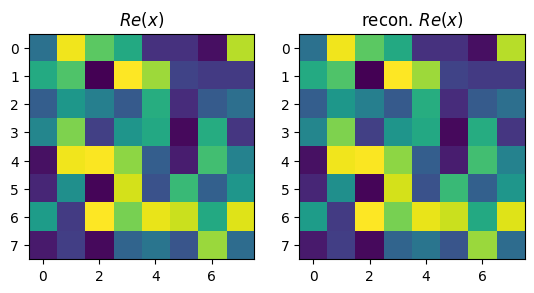

In [ ]:
# --- Generate 2D complex input ---
np.random.seed(42)
x = np.random.rand(8, 8).astype(np.float32)
x = tf.cast(x, tf.complex64)

# --- Compute using tf.signal.fft2d ---
fft2d_direct = tf.signal.fft2d(x)

# --- Compute using fftnd, i.e., separable 1D FFTs ---
fft2d_separable = fftnd(x, axes=[0, 1])

# --- Compare results ---
difference = tf.abs(fft2d_direct - fft2d_separable)
max_diff = tf.reduce_max(difference)

print("Max absolute difference between tf.signal.fft2d and separable nd_fft:", max_diff.numpy())

xhat = ifftnd(fft2d_separable, axes=[0, 1])
error = tf.reduce_max(tf.abs(xhat - x))
print("Max reconstruction error:", error.numpy())
import matplotlib.pyplot as plt
plt.subplot(121), plt.imshow(np.real(x)), plt.title('$Re(x)$')
plt.subplot(122),plt.imshow(np.real(xhat)), plt.title('recon. $Re(x)$')
del x, xhat, error, max_diff, difference, fft2d_direct, fft2d_separable


In [ ]:
whos

Variable       Type           Data/Info
---------------------------------------
axes           EagerTensor    tf.Tensor([1 2 3 4], shape=(4,), dtype=int32)
fft4d          function       <function fft4d at 0x7f9074770900>
fft_length     EagerTensor    tf.Tensor([4 4 4 4], shape=(4,), dtype=int32)
fftnd          function       <function fftnd at 0x7f9074770f40>
gpus           list           n=3
ifft4d         function       <function ifft4d at 0x7f9074770180>
ifftnd         function       <function ifftnd at 0x7f9074770b80>
memory_limit   int            32
np             module         <module 'numpy' from '/da<...>kages/numpy/__init__.py'>
plt            module         <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
select_a_gpu   function       <function select_a_gpu at 0x7f91229fff60>
sys            module         <module 'sys' (built-in)>
tf             module         <module 'tensorflow' from<...>/tensorflow/__init__.py'>


    Multichannel input: checking separable and nonseparable FFT 2D with channel dim

In [ ]:
# Create random complex data: (batch, height, width, channels)
batch, height, width, channels = 2, 4, 4, 100
np.random.seed(0)
x = np.random.rand(batch, height, width, channels).astype(np.float32)
x = tf.cast(x, tf.complex64)

# Separable FFT2D: FFT over spatial dims using fftnd
xfft_separable = fftnd(x, axes=[1, 2])

# Nonseparable FFT2D: reshape and apply tf.signal.fft2d on last two dims
x_transposed = tf.transpose(x, perm=[0, 3, 1, 2])  # (batch, channels, height, width)
x_reshaped = tf.reshape(x_transposed, [-1, height, width])  # (batch*channels, height, width)
xfft_manual = tf.signal.fft2d(x_reshaped)
xfft_manual = tf.reshape(xfft_manual, [batch, channels, height, width])
xfft_manual = tf.transpose(xfft_manual, perm=[0, 2, 3, 1])  # back to (batch, height, width, channels)

# Compare
diff = tf.abs(xfft_separable - xfft_manual)
max_diff = tf.reduce_max(diff)

print(f">> {max_diff.numpy()} is the max absolute difference between fftnd(x) and manual fft2d(x), where x is multichannel input")

>> 0.0 is the max absolute difference between fftnd(x) and manual fft2d(x), where x is multichannel input


In [ ]:
# ---- Inverse FFT ----

# Inverse FFT using nd_ifft
x_ifft_separable = ifftnd(xfft_separable, axes=[1, 2])
# x_ifft_nd *= (height * width)  # Scale because FFT/IFFT unnormalized

# Manual inverse FFT: reshape and apply tf.signal.ifft2d on last two dims
xfft_manual_transposed = tf.transpose(xfft_manual, perm=[0, 3, 1, 2])  # (batch, channels, height, width)
xfft_manual_reshaped = tf.reshape(xfft_manual_transposed, [-1, height, width])
x_ifft_manual = tf.signal.ifft2d(xfft_manual_reshaped)
x_ifft_manual = tf.reshape(x_ifft_manual, [batch, channels, height, width])
x_ifft_manual = tf.transpose(x_ifft_manual, perm=[0, 2, 3, 1])
# x_ifft_manual *= (height * width)  # Scale inverse

# Compare inverse FFT results
diff_inverse = tf.abs(x_ifft_separable - x_ifft_manual)
max_diff_inverse = tf.reduce_max(diff_inverse)
print("Max abs diff between ifftnd and manual ifft2d:", max_diff_inverse.numpy())


# Verify reconstruction error fft2d and ifft2d
recon_error_nd = tf.reduce_max(tf.abs(x_ifft_manual - x))
print("(Nonseparable) Max reconstruction error (ifft2d):", recon_error_nd.numpy())


# Verify reconstruction error fftnd and ifftnd
recon_error_nd = tf.reduce_max(tf.abs(x_ifft_separable - x))
print("(Separable)    Max reconstruction error (ifftnd):", recon_error_nd.numpy())

Max abs diff between ifftnd and manual ifft2d: 0.0
(Nonseparable) Max reconstruction error (ifft2d): 1.7881393e-07
(Separable)    Max reconstruction error (ifftnd): 1.7881393e-07


In [ ]:
del batch, height, width, channels, x, x_transposed, x_reshaped, xfft_manual, diff, max_diff, xfft_separable
del x_ifft_separable, xfft_manual_transposed, xfft_manual_reshaped, x_ifft_manual, diff_inverse, max_diff_inverse, recon_error_nd

In [ ]:
whos

Variable       Type           Data/Info
---------------------------------------
axes           EagerTensor    tf.Tensor([1 2 3 4], shape=(4,), dtype=int32)
fft4d          function       <function fft4d at 0x7f9074770900>
fft_length     EagerTensor    tf.Tensor([4 4 4 4], shape=(4,), dtype=int32)
fftnd          function       <function fftnd at 0x7f9074770f40>
gpus           list           n=3
ifft4d         function       <function ifft4d at 0x7f9074770180>
ifftnd         function       <function ifftnd at 0x7f9074770b80>
memory_limit   int            32
np             module         <module 'numpy' from '/da<...>kages/numpy/__init__.py'>
plt            module         <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
select_a_gpu   function       <function select_a_gpu at 0x7f91229fff60>
sys            module         <module 'sys' (built-in)>
tf             module         <module 'tensorflow' from<...>/tensorflow/__init__.py'>


        Another self sanity check of reconstuction of fftnd

In [ ]:
import numpy as np

# Shape: (batch_size=2, D1=4, D2=4, D3=4, D4=4)
x = np.random.rand(2, 4, 4, 4, 4, 100).astype(np.float32)
x = tf.cast(x, tf.complex64)

# Apply 4D FFT over last 4 axes
xfft = fftnd(x, axes=[1, 2, 3, 4])

# Inverse FFT to recover original signal
xhat = ifftnd(xfft, axes=[1, 2, 3, 4])

# Check reconstruction error
error = tf.reduce_max(tf.abs(xhat - x))
print("Max reconstruction error:", error.numpy())


Max reconstruction error: 2.9802322e-07


In [ ]:
x[0,0,:,:,0,0], xhat[0,0,:,:,0,0]

(<tf.Tensor: shape=(4, 4), dtype=complex64, numpy=
 array([[0.21809302+0.j, 0.84978616+0.j, 0.557293  +0.j, 0.12955707+0.j],
        [0.92632586+0.j, 0.7788137 +0.j, 0.04365822+0.j, 0.86269677+0.j],
        [0.3694665 +0.j, 0.00619509+0.j, 0.5734739 +0.j, 0.3499428 +0.j],
        [0.25719255+0.j, 0.16222318+0.j, 0.9279548 +0.j, 0.02784515+0.j]],
       dtype=complex64)>,
 <tf.Tensor: shape=(4, 4), dtype=complex64, numpy=
 array([[0.21809295+0.j, 0.84978604+0.j, 0.55729294+0.j, 0.12955704+0.j],
        [0.92632574+0.j, 0.7788137 +0.j, 0.04365815+0.j, 0.8626967 +0.j],
        [0.36946645+0.j, 0.00619504+0.j, 0.57347375+0.j, 0.34994274+0.j],
        [0.25719243+0.j, 0.16222304+0.j, 0.9279548 +0.j, 0.02784509+0.j]],
       dtype=complex64)>)

In [ ]:
del x, xfft, xhat, error

In [ ]:
input_tensor = tf.zeros([8, 4, 4, 4, 4, 4, 4, 8, 16])  # Example shape: [batch, N, N, N, N, N, N, channels]
input_shape  = input_tensor.shape
axes = list(range(1, len(input_shape) - 1))
axes, len(axes)
# input_shape

([1, 2, 3, 4, 5, 6, 7], 7)

In [ ]:
list(range(tf.rank(input_tensor)))

[0, 1, 2, 3, 4, 5, 6, 7, 8]

In [ ]:
list(range(len(tf.shape(input_tensor))))

[0, 1, 2, 3, 4, 5, 6, 7, 8]

In [ ]:
tf.shape(input_tensor)

<tf.Tensor: shape=(9,), dtype=int32, numpy=array([ 8,  4,  4,  4,  4,  4,  4,  8, 16], dtype=int32)>

In [ ]:
list(range(input_tensor.shape.rank))

[0, 1, 2, 3, 4, 5, 6, 7, 8]

In [ ]:
list(range(1, len(input_shape) - 1))

[1, 2, 3, 4, 5, 6, 7, 8, 9]

In [ ]:
list(range(1, input_shape.rank - 1))

AttributeError: 'tuple' object has no attribute 'rank'